In [1]:
using JLD2
using Plots
using SpecialFunctions
using Printf

In [87]:
using JLD2

const SWEEP_DIRS = [
    "finer_IsingML_L8,16_sweep",
    "finer_IsingML_L8,16_sweep2",
    "finer_IsingML_L8,16_sweep3",
    "IsingML_L8_sweep",
    "IsingML_L16_sweep",
    "IsingML_L8,24_sweep",
    "IsingML_L12,16_sweep",
    "IsingML_fineq_sweep",
    "MV_L20_sweep",
    "MV_L40_sweep",
    "MV_L60_sweep",
    "MV_L80_sweep",
]

const OUTPUT_ROOT = joinpath(@__DIR__, "..", "output")

function merge_entries(a::NamedTuple, b::NamedTuple)::NamedTuple
    n_a = a.total_samples
    n_b = b.total_samples
    n   = n_a + n_b
    return (
        M1s                 = (n_a .* a.M1s  .+ n_b .* b.M1s)  ./ n,
        M2s                 = (n_a .* a.M2s  .+ n_b .* b.M2s)  ./ n,
        E1s                 = (n_a .* a.E1s  .+ n_b .* b.E1s)  ./ n,
        E2s                 = (n_a .* a.E2s  .+ n_b .* b.E2s)  ./ n,
        instant_failures    = (n_a .* a.instant_failures    .+ n_b .* b.instant_failures)    ./ n,
        cumulative_failures = (n_a .* a.cumulative_failures .+ n_b .* b.cumulative_failures) ./ n,
        Ms_hist             = a.Ms_hist .+ b.Ms_hist,
        Es_hist             = a.Es_hist .+ b.Es_hist,
        total_samples       = n,
        total_time          = a.total_time + b.total_time,
    )
end

collate_files = String[]
for dir in SWEEP_DIRS
    path = joinpath(OUTPUT_ROOT, dir)
    isdir(path) || continue
    for (dirpath, _, filenames) in walkdir(path)
        if "collated_results.jld2" in filenames
            push!(collate_files, joinpath(dirpath, "collated_results.jld2"))
        end
    end
end

all_results = Dict{NTuple{6,Any}, NamedTuple}()
collisions  = 0

for fpath in collate_files
    for ((tag, algo, L, T, p, q, c), entry) in load(fpath, "results")
        key = (algo, L, T, p, q, c)
        if haskey(all_results, key)
            all_results[key] = merge_entries(all_results[key], entry)
            collisions += 1
        else
            all_results[key] = entry
        end
    end
end

println("$(length(all_results)) unique parameter sets, $collisions collision(s) merged.")

46354 unique parameter sets, 1194 collision(s) merged.


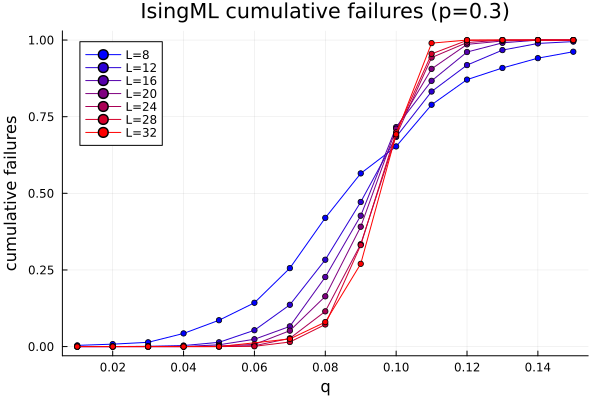

In [86]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][2L] for q in valid_qs]
    plot!(plt, valid_qs, cf, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="q", ylabel="cumulative failures", title="$algo cumulative failures (p=$p)")
plt

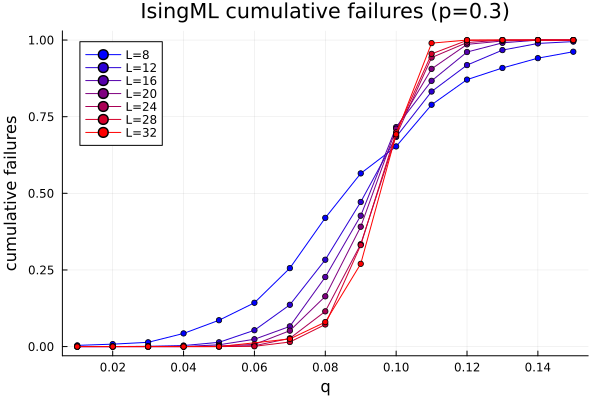

In [52]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf2 = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][2L] for q in valid_qs]
    cf4 = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][4L] for q in valid_qs]
    plot!(plt, valid_qs, cf2, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="q", ylabel="cumulative failures", title="$algo cumulative failures (p=$p)")
plt

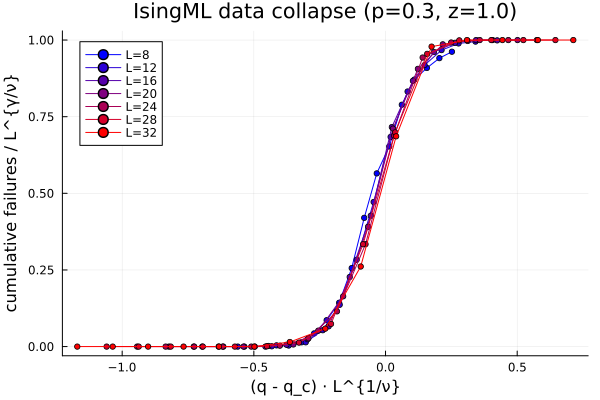

In [177]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
qc   = 0.097
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

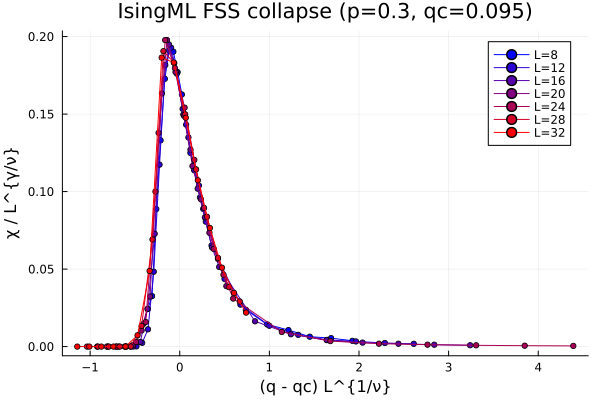

In [178]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.5
qc   = 0.095
ν    = 4/3
γ_ν  = 2.0
z    = 1.0
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

In [ ]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

c    = 0.05
qs   = 0.01:0.01:0.15
qc   = 0.097
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

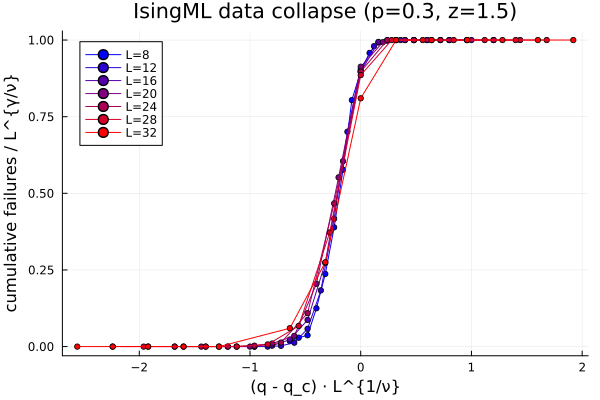

In [65]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
qc   = 0.09
ν    = 1.0
z    = 1.5
γ_ν  = 0

plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν)
          for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf,
          m=3, label="L=$L", color=colors[i])
end

plot!(plt,
      xlabel = "(q - q_c) · L^{1/ν}",
      ylabel = "cumulative failures / L^{γ/ν}",
      title  = "$algo data collapse (p=$p, z=$z)")
plt

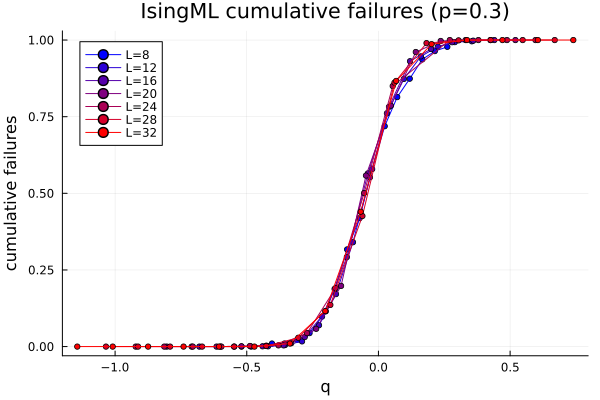

In [332]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 1.0
qs   = 0.01:0.01:0.15
qc = 0.095
ν = 4/3
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][2L] for q in valid_qs]
    plot!(plt, (valid_qs .- qc) * L^(1/ν), cf, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="q", ylabel="cumulative failures", title="$algo cumulative failures (p=$p)")
plt

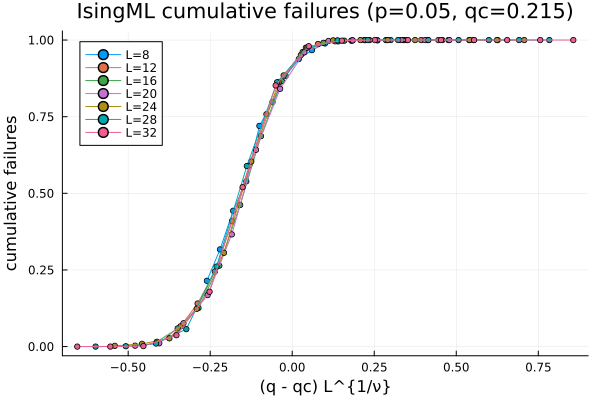

In [130]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.15:0.01:0.3
qc = 0.215
ν = 1.5
plt = plot()
for L in Ls
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][10L] for q in valid_qs]
    
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L")
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="cumulative failures", title="$algo cumulative failures (p=$p, qc=$(round(qc,digits=3)))")
plt

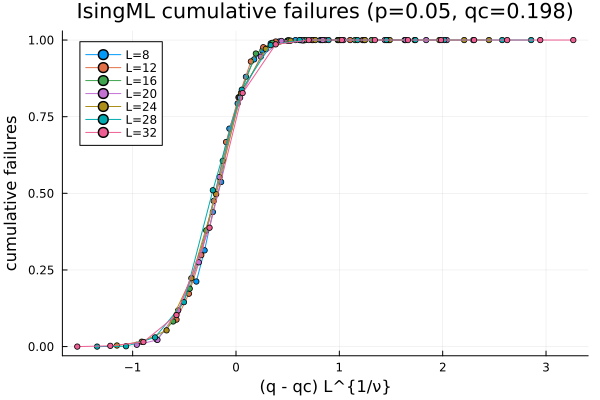

In [129]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.15:0.01:0.3
qc = 0.198
ν = 1.0
plt = plot()
for L in Ls
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][floor(Int, 3.5L^1.5)] for q in valid_qs]
    
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L")
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="cumulative failures", title="$algo cumulative failures (p=$p, qc=$(round(qc,digits=3)))")
plt

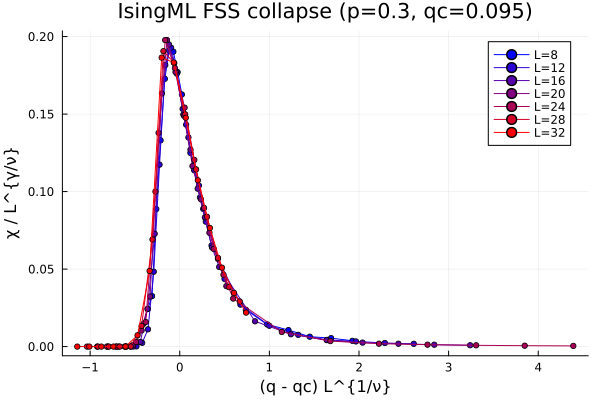

In [166]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.5
qc   = 0.095
ν    = 4/3
γ_ν  = 2.0
z    = 1.0
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

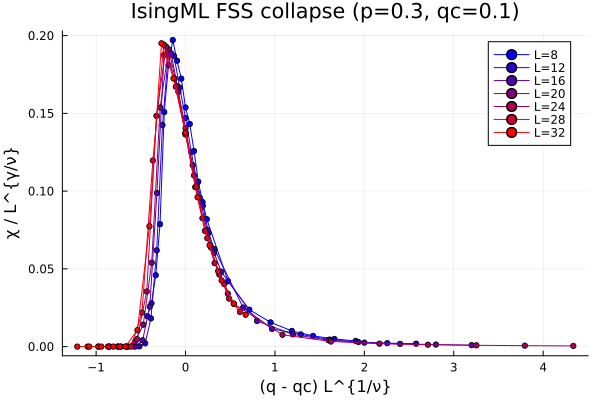

In [99]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 1.0
qs   = 0.01:0.01:0.5
qc   = 0.1
ν    = 4/3
γ_ν  = 2.0
z    = 1.0
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

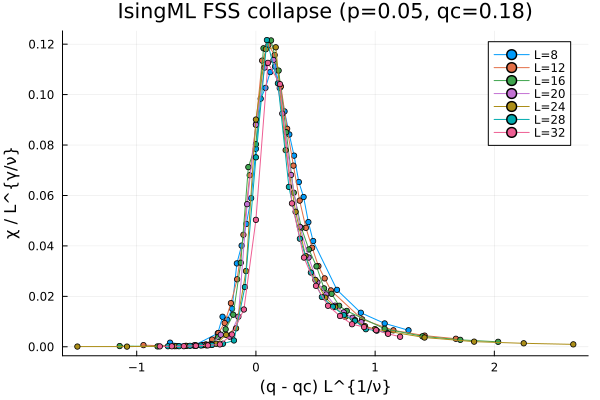

In [342]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.0:0.01:0.5
qc   = 0.18
ν    = 1.5
γ_ν  = 7/4
z    = 1.5
plt = plot()
for L in Ls
    T = 20L
    t = round(Int, T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L")
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

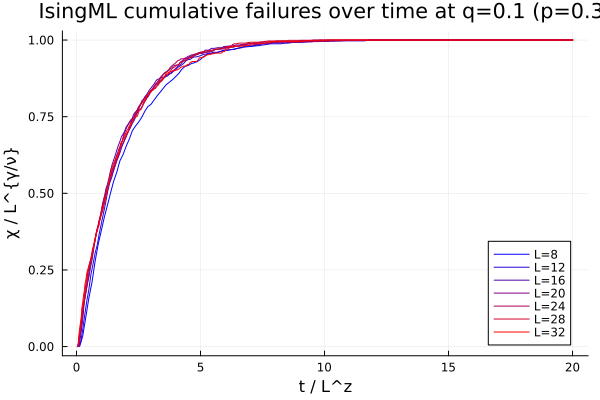

In [12]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
q   = 0.1
c = 0.8
z    = 1.0
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:cumulative_failures])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

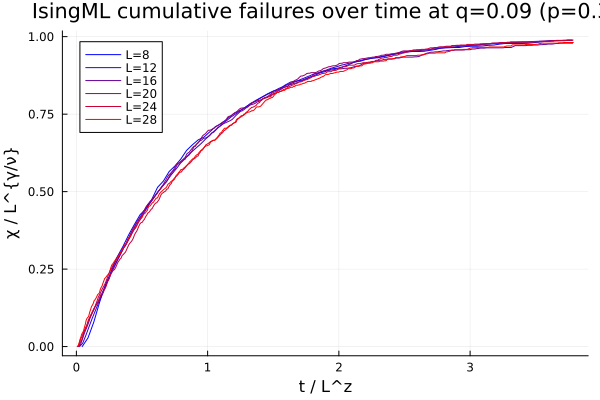

In [81]:
algo = "IsingML"
Ls   = 8:4:28
p    = 0.3
q   = 0.09
c = 0.8
z    = 1.5
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

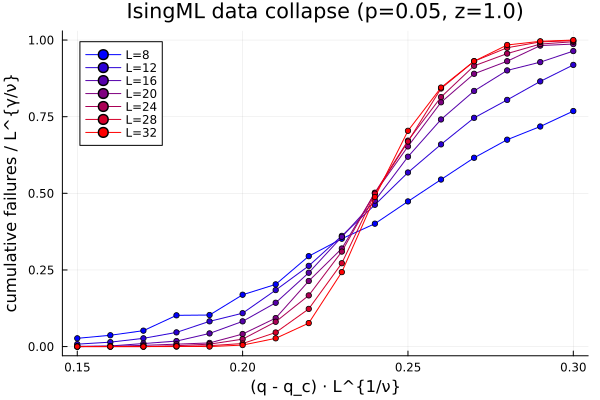

In [64]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.0
qs   = 0.15:0.01:0.3
qc   = 0.0
ν    = Inf
z    = 1.0
γ_ν  = 0

plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν)
          for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf,
          m=3, label="L=$L", color=colors[i])
end

plot!(plt,
      xlabel = "(q - q_c) · L^{1/ν}",
      ylabel = "cumulative failures / L^{γ/ν}",
      title  = "$algo data collapse (p=$p, z=$z)")
plt

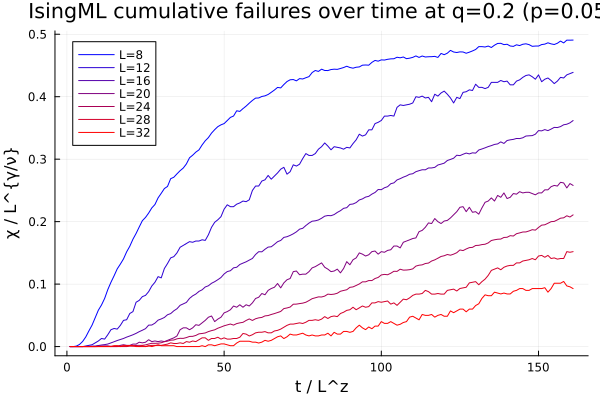

In [55]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.2
c = 0.05
z    = 0.0
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:instant_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

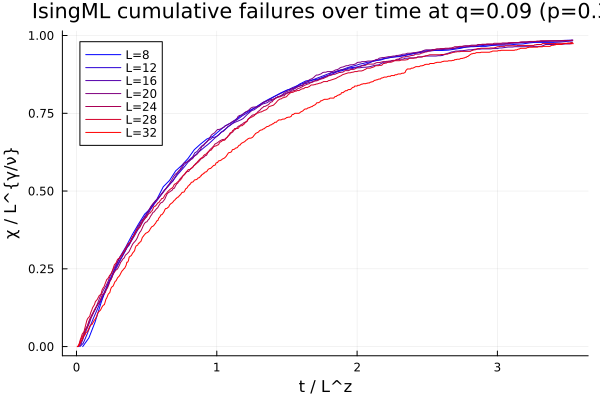

In [97]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
q   = 0.09
c = 0.8
z    = 1.5
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:cumulative_failures])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

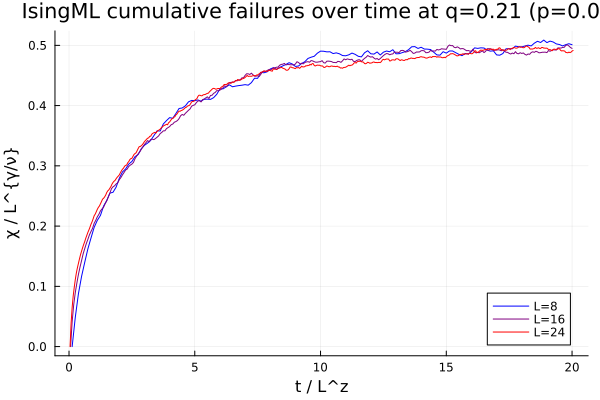

In [207]:
algo = "IsingML"
Ls   = 8:8:28
p    = 0.05
q   = 0.21
c = 0.05
z    = 1.0
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:cumulative_failures])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:M1s] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

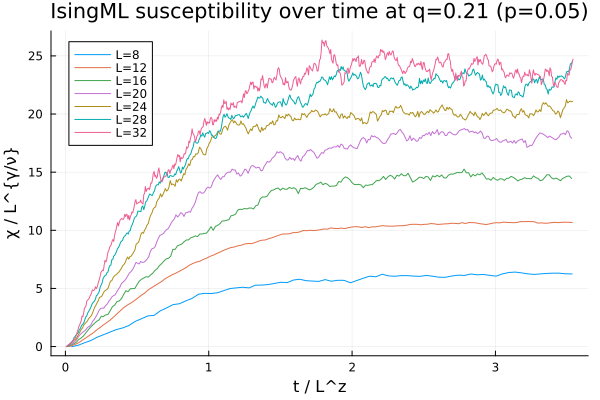

In [169]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.21
c = 0.05

f(L) = L^1.5
γ_ν  = 0.0

scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ f(L)
             for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]

t_max = minimum(maximum.(scaled_ts))

plt = plot()
for L in Ls
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:M1s]
    M2s = all_results[(algo, L, T, p, q, c)][:M2s]
    χ   = L^2 .* (M2s .- M1s.^2)
    ts  = collect(1:length(M1s)) ./ f(L)
    mask = ts .<= t_max
    plot!(plt, ts[mask], χ[mask] ./ L^γ_ν, label="L=$L")
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo susceptibility over time at q=$q (p=$p)")
plt